# Machine Learning Lab 3 — Decision Tree Classification

**Name:** Sadia Fatima
**CMS:** 023-24-0213
**Section:** G
**GitHub Profile:** https://github.com/Sadia-Farooque/Machine_Learning.git
**Kaggle Profile:**https://www.kaggle.com/anamfarooque



# 1. Problem Definition

## task2. Problem Definition

The goal is to predict whether a telecom customer will churn based on their demographic, service, contract, and billing information. This is useful for the business because identifying customers who are likely to leave can help the company take steps to improve customer retention.


# 2. Dataset Verification



In [10]:
# Task 1:

import pandas as  p 

df = p.read_csv("clean_churn.csv")
df.head()
print(df.shape)
df.info()
df.isnull().sum() # missin values
df ['Churn'].value_counts()




(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Interpretation:** The dataset has **7,043 rows and 20 columns** and there are no missing values. Most customers did not churn (**5,174 customers or about 73.5%**), while **1,869 customers (about 26.5%)** did churn. This shows that the target variable is imbalanced, so accuracy alone may not give us a complete picture of the model's performance.


# 3. Feature/Target Preparation

In [11]:
#task 3:

y=df['Churn'].map({'No': 0,'Yes': 1})
x=df.drop(columns=['Churn'])

print("y: ")
print(y.head())

print("\nx: ")
print(x.head())

y: 
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

x: 
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          

**Interpretation:** The target variable y is changed into numbers, where **No = 0** and **Yes = 1**, so the model can work with it. The feature set x contains all the other columns except Churn, including numerical features like tenure and MonthlyCharges and categorical features like gender, Contract, and InternetService, which need to be converted into numbers before training the model.


In [12]:
#task4: 
x= p.get_dummies(x,dtype=int) #get_dummies() automatically finds the categorical columns and converts them into numeric columns.

print(x.head())

# I used one-hot encoding because the categorical features do not
#  have a natural numerical order. It converts each category into 
#  separate 0/1 columns without incorrectly implying that one category
#   is greater or smaller than another.


   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Female  \
0              0       1           29.85         29.85              1   
1              0      34           56.95       1889.50              0   
2              0       2           53.85        108.15              0   
3              0      45           42.30       1840.75              0   
4              0       2           70.70        151.65              1   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  Dependents_Yes  ...  \
0            0           0            1              1               0  ...   
1            1           1            0              1               0  ...   
2            1           1            0              1               0  ...   
3            1           1            0              1               0  ...   
4            0           1            0              1               0  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0               

One-hot encoding converts each categorical value into separate 0/1 columns. Because of this, the feature set increased to 45 numeric columns. This is useful because it lets the model work with categorical data without treating categories as if they have a natural order.

In [ ]:
#task5:
print("Missing values: ")
print(x.isnull().sum().sum())

print("\nDatatpes : ")
print(x.dtypes)

print("\nare all columns nmerical ? ")
print(x.select_dtypes(include='number').shape==x.shape)

Missing values: 
0

Datatpes : 
SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                                int64
gender_Male                                  int64
Partner_No                                   int64
Partner_Yes                                  int64
Dependents_No                                int64
Dependents_Yes                               int64
PhoneService_No                              int64
PhoneService_Yes                             int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No                           int64
OnlineSecurity_No                            int64

Interpretation: After encoding, X has no missing values and all of its columns are numeric. This means the data is now ready to be used with the Decision Tree, since the model needs numerical values to make its predictions.

# 4. Train/Test Split

In [ ]:
# task6:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test =train_test_split (
    x,y,test_size=0.2, random_state=42,stratify=y
)

# I used `stratify=y` so that the training and test 
# sets maintain approximately the same proportion of 
# Churn classes as the original dataset. This is
#  important because the target classes may be imbalanced,
#  and a simple random split could give an unrepresentative
#  class distribution.


In [ ]:
# task7:
print("x_train: ",x_train.shape)
print("x_tst: ",x_test.shape)
print("y_train: ",y_train.shape)
print("y_test: ",y_test.shape)

x_train:  (5634, 45)
x_tst:  (1409, 45)
y_train:  (5634,)
y_test:  (1409,)


Interpretation: The data was divided into 80% training data and 20% test data, giving us 5,634 training rows and 1,409 test rows. We used stratify=y to keep the same proportion of churn and non-churn customers in both sets, making the test data more representative and reliable for evaluating the model.

# 5. Baseline Decision Tree

In [ ]:
# task8:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

y_train_pred = dt.predict(x_train)
y_test_pred = dt.predict(x_test)

In [ ]:
# task9:
print("Depth: ",dt.get_depth())

# The Decision Tree grew to a depth of 22 using the default settings. 
# This is somewhat expected because no maximum depth was specified, 
# allowing the tree to keep splitting the training data until the 
# default stopping conditions were reached. The relatively deep 
# tree may also indicate a risk of overfitting, which we will 
# evaluate using the test data.


Depth:  22


# 6. Model Evaluation

In [ ]:
# task10:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

results = p.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [accuracy, precision, recall, f1]
})

results

Accuracy : 0.7288857345635202
Precision: 0.4896373056994819
Recall   : 0.5053475935828877
F1-score : 0.49736842105263157


,Metric,Score
0,Accuracy,0.728886
1,Precision,0.489637
2,Recall,0.505348
3,F1-score,0.497368


Interpretation: On the test set, the unrestricted baseline tree achieved 72.9% accuracy, but its precision, recall, and F1-score were much lower. This shows that accuracy alone does not give a clear picture of how well the model identifies churners, especially because the dataset is imbalanced. The model still misses many actual churners and also makes a fair number of incorrect churn predictions.

[[838 197]
 [185 189]]


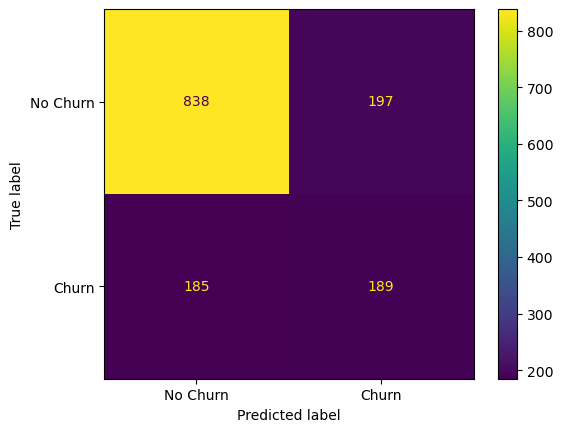

In [ ]:
# task11:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()

print(cm)

# The model correctly identified **189 actual churners**, 
# while it missed **185 actual churners**. This shows that
#  the baseline tree still fails to identify a substantial number
#  of customers who actually churned.


In [ ]:
# task12:
# Because the Churn classes are imbalanced, accuracy
# alone may give a misleading picture of model performance.
# I trust recall most because the business wants to identify as
# many actual churners as possible, while F1-score is also useful
# because it balances recall with precision.


# 7. Overfitting Experiment

In [ ]:
# task13:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Gap:", train_accuracy - test_accuracy)

# The baseline Decision Tree achieved a training accuracy of **99.80%**, 
# but its test accuracy was only **72.89%**, giving a large gap of 
# approximately **26.92 percentage points**. This suggests that the
#  unrestricted tree has overfit the training data and learned patterns
#  that do not generalize well to unseen customers.


Training Accuracy: 0.9980475683351083
Test Accuracy: 0.7288857345635202
Gap: 0.2691618337715881


In [ ]:
# task14:
depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(x_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(x_train))
    test_acc = accuracy_score(y_test, model.predict(x_test))

    results.append({
        'max_depth': depth if depth is not None else 'unrestricted',
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

depth_results = p.DataFrame(results)

depth_results

,max_depth,train_accuracy,test_accuracy
0,2,0.765353,0.750887
1,3,0.791445,0.782115
2,4,0.796592,0.792051
3,5,0.803869,0.798439
4,6,0.810437,0.791341
5,8,0.837238,0.774308
6,10,0.878417,0.753726
7,unrestricted,0.998048,0.728886


Interpretation: As max_depth increases, the training accuracy keeps improving, reaching about 99.8% for the unrestricted tree. However, test accuracy reaches its highest point at max_depth = 5 with about 79.8% and then starts to decrease. This shows that deeper trees begin to overfit the training data and do not perform as well on new data.

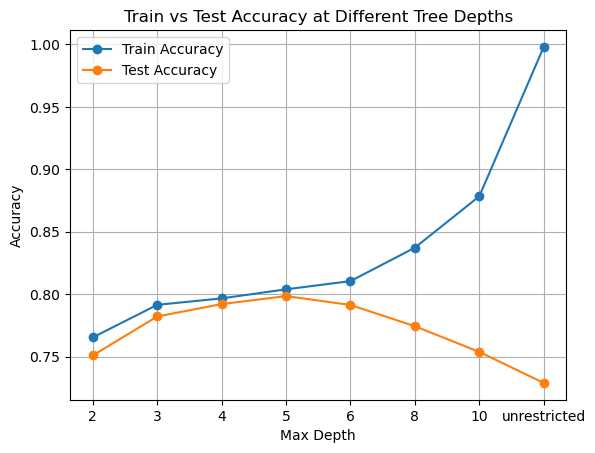

In [ ]:
# task15:
import matplotlib.pyplot as plt

x_axis = range(len(depth_results))

plt.plot(x_axis, depth_results['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(x_axis, depth_results['test_accuracy'], marker='o', label='Test Accuracy')

plt.xticks(x_axis, depth_results['max_depth'])
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy at Different Tree Depths')
plt.legend()
plt.grid(True)
plt.show()

# The model starts to show overfitting at around **depth 6**.
#  Up to depth 5, test accuracy improves while training and 
# test accuracy remain close, but after this point training accuracy 
# continues to increase while test accuracy begins to decrease.
#  The widening gap between the two curves shows that deeper trees
#  are fitting the training data increasingly well without improving 
# generalization.

In [ ]:
# task16:
# I selected **max_depth = 5** as the best model because
#  it achieved the highest test accuracy of approximately 
# **79.84%** while keeping the training accuracy close at
#  **80.39%**. Unlike deeper trees, it provides a good balance
#  between predictive performance and generalization, with only
#  a small gap between training and test accuracy.


# 8. Model Comparison

In [ ]:
# task17:
best_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

best_model.fit(x_train, y_train)

y_test_best = best_model.predict(x_test)

best_accuracy = accuracy_score(y_test, y_test_best)
best_precision = precision_score(y_test, y_test_best)
best_recall = recall_score(y_test, y_test_best)
best_f1 = f1_score(y_test, y_test_best)

best_results = p.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [
        best_accuracy,
        best_precision,
        best_recall,
        best_f1
    ]
})

best_results

# The depth-5 Decision Tree achieved **79.84% accuracy, 
# 63.47% precision, 56.68% recall, and 59.89% F1-score** 
# on the test set. Compared with the unrestricted baseline,
#  the depth-limited model generalizes better to unseen data 
# and provides a more reliable model despite being less complex.


,Metric,Score
0,Accuracy,0.798439
1,Precision,0.634731
2,Recall,0.566845
3,F1-score,0.598870


In [ ]:
# task18:
entropy_model = DecisionTreeClassifier(
    max_depth=5,
    criterion='entropy',
    random_state=42
)

entropy_model.fit(x_train, y_train)

y_test_entropy = entropy_model.predict(x_test)

entropy_accuracy = accuracy_score(y_test, y_test_entropy)
entropy_precision = precision_score(y_test, y_test_entropy)
entropy_recall = recall_score(y_test, y_test_entropy)
entropy_f1 = f1_score(y_test, y_test_entropy)

entropy_results = p.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})

entropy_results

# The entropy-based Decision Tree achieved **79.70% accuracy,
#  63.10% precision, 56.68% recall, and 59.72% F1-score**.
#  Its performance was very similar to the Gini-based depth-5 model,
#  but Gini performed slightly better on accuracy, precision, 
# and F1-score, so I would retain the Gini model as the preferred model.


,Metric,Score
0,Accuracy,0.797019
1,Precision,0.630952
2,Recall,0.566845
3,F1-score,0.597183


Interpretation: The Gini and entropy models with max_depth = 5 gave very similar results. The Gini model performed slightly better in accuracy, precision, and F1-score, while both models had the same recall. Therefore, we kept the Gini model as the final model since it gave slightly better overall performance.

# 9. Feature Importance

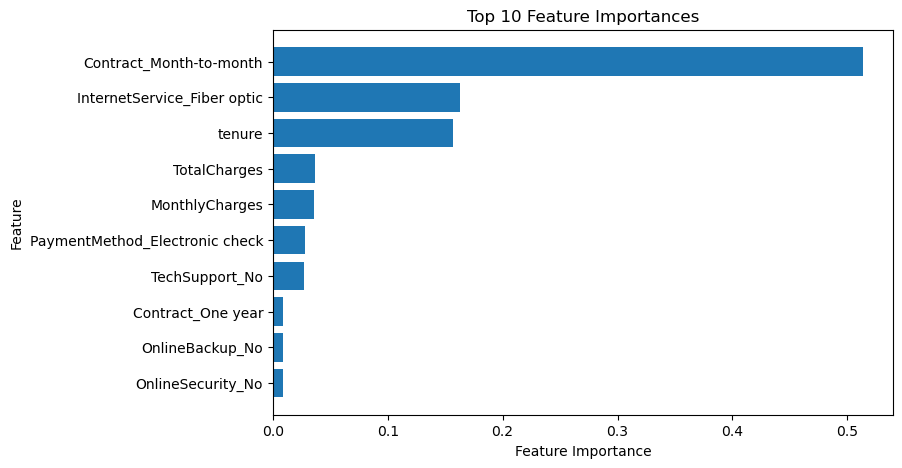

In [ ]:
# task19:
importances = best_model.feature_importances_

feature_importance = p.Series(
    importances,
    index=x.columns
).sort_values(ascending=False)

feature_importance.head(10)

top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(top_features.index, top_features.values)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.show()

In [ ]:
#task 20 
# The feature importance results agree with the
#  patterns observed in Lab 2's EDA. **Month-to-month contracts** 
# were strongly associated with higher churn, while **tenure** 
# showed that customers with longer relationships were generally 
# less likely to churn. Internet service also appears among the most
#  important features, suggesting that the type of service is useful
#  for distinguishing customers who churn from those who stay.


# 11. Conclusion

In [ ]:
# # task 21
# I built a Decision Tree classification model to
#  predict whether customers would churn or stay.
#  The unrestricted baseline tree overfit the training data,
#  achieving 99.80% training accuracy but only 72.89% test accuracy. 
# After testing different depths, I selected a Gini Decision Tree with
#  `max_depth=5`, which achieved 79.84% accuracy, 63.47% precision, 56.68%
#  recall, and 59.89% F1-score on the test set. The depth-limited model
#  generalized better than the unrestricted tree and provided a better
#  balance between training and test performance. However, its recall
#  shows that it still misses a considerable number of actual churners,
#  and the model may benefit from better handling of class imbalance and
#  additional feature engineering.


In [ ]:
# # task 22
# If I had more time, I would first investigate methods
#  for handling the class imbalance so that the model can 
# improve its ability to identify actual churners. I would also
#  perform additional feature engineering to create more informative 
# customer behavior features. Finally, I would compare the Decision 
# Tree with other suitable classification algorithms and evaluate them
#  using recall and F1-score rather than relying only on accuracy.


In [26]:
# task23
play_badminton = p.DataFrame({
    'Outlook': [
        'Sunny', 'Sunny', 'Overcast', 'Rain',
        'Rain', 'Rain', 'Overcast', 'Sunny',
        'Sunny', 'Rain', 'Sunny', 'Overcast',
        'Overcast', 'Rain'
    ],
    
    'Temperature': [
        'Hot', 'Hot', 'Hot', 'Mild',
        'Cool', 'Cool', 'Cool', 'Mild',
        'Cool', 'Mild', 'Mild', 'Mild',
        'Hot', 'Mild'
    ],
    
    'Humidity': [
        'High', 'High', 'High', 'High',
        'Normal', 'Normal', 'Normal', 'High',
        'Normal', 'Normal', 'Normal', 'High',
        'Normal', 'High'
    ],
    
    'Wind': [
        'Weak', 'Strong', 'Weak', 'Weak',
        'Weak', 'Strong', 'Strong', 'Weak',
        'Weak', 'Weak', 'Strong', 'Strong',
        'Weak', 'Strong'
    ],
    
    'Play': [
        'No', 'No', 'Yes', 'Yes',
        'Yes', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No'
    ]
})

play_badminton


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [33]:
import math 
def entropy(data , target ):
    values = data [target].value_counts()
    total =len (data)

    ent = 0 

    for count in values:
        probability = count / total
        ent -= probability * math.log2(probability)

    return ent

entropy(play_badminton, 'Play')


0.9402859586706311

In [34]:
def information_gain(data, attribute, target):
    total_entropy = entropy(data, target)

    weighted_entropy = 0

    for value in data[attribute].unique():
        subset = data[data[attribute] == value]

        weight = len(subset) / len(data)

        subset_entropy = entropy(subset, target)

        weighted_entropy += weight * subset_entropy

    gain = total_entropy - weighted_entropy

    return gain

In [35]:
attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']

for attribute in attributes:
    gain = information_gain(
        play_badminton,
        attribute,
        'Play'
    )

    print(attribute, ":", gain)

def best_attribute(data, attributes, target):
    gains = {}

    for attribute in attributes:
        gains[attribute] = information_gain(
            data,
            attribute,
            target
        )

    best = max(gains, key=gains.get)

    print("Information Gain:")

    for attribute, gain in gains.items():
        print(f"{attribute}: {gain:.4f}")

    print("\nBest attribute:", best)

    return best

remaining_attributes = [
    'Outlook',
    'Temperature',
    'Humidity',
    'Wind'
]

best_attribute(
    play_badminton,
    remaining_attributes,
    'Play'
)


Outlook : 0.24674981977443933
Temperature : 0.02922256565895487
Humidity : 0.15183550136234159
Wind : 0.04812703040826949
Information Gain:
Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Wind: 0.0481

Best attribute: Outlook


'Outlook'

In [36]:
def id3(data, attributes, target, level=0):
    
    indent = "  " * level

    # If all examples belong to one class
    if len(data[target].unique()) == 1:
        return data[target].iloc[0]

    # If no attributes remain
    if len(attributes) == 0:
        return data[target].mode()[0]

    print("\n" + indent + "Current split")
    
    best = best_attribute(data, attributes, target)

    tree = {best: {}}

    remaining_attributes = [
        attr for attr in attributes
        if attr != best
    ]

    for value in data[best].unique():

        print(indent + f"\nBranch: {best} = {value}")

        subset = data[data[best] == value]

        tree[best][value] = id3(
            subset,
            remaining_attributes,
            target,
            level + 1
        )

    return tree

attributes = [
    'Outlook',
    'Temperature',
    'Humidity',
    'Wind'
]

id3_tree = id3(
    play_badminton,
    attributes,
    'Play'
)

id3_tree


Current split
Information Gain:
Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Wind: 0.0481

Best attribute: Outlook

Branch: Outlook = Sunny

  Current split
Information Gain:
Temperature: 0.5710
Humidity: 0.9710
Wind: 0.0200

Best attribute: Humidity
  
Branch: Humidity = High
  
Branch: Humidity = Normal

Branch: Outlook = Overcast

Branch: Outlook = Rain

  Current split
Information Gain:
Temperature: 0.0200
Humidity: 0.0200
Wind: 0.9710

Best attribute: Wind
  
Branch: Wind = Weak
  
Branch: Wind = Strong


{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}},
  'Overcast': 'Yes',
  'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}

Interpretation: The overall entropy of the Play target is about 0.940, which means the dataset has a fairly mixed number of Yes and No outcomes. Among all the attributes, Outlook has the highest information gain at about 0.247, followed by Humidity, Wind, and Temperature. Therefore, ID3 selects Outlook as the root of the tree, and then continues choosing the best attribute for each branch.

## Submission Checklist

- [x] 1. Problem Definition
- [x] 2. Dataset Verification
- [x] 3. Feature/Target Preparation
- [x] 4. Train/Test Split
- [x] 5. Baseline Decision Tree
- [x] 6. Model Evaluation (accuracy, precision, recall, F1, confusion matrix)
- [x] 7. Overfitting Experiment (train-vs-test comparison + multi-depth experiment)
- [x] 8. Model Comparison (Gini vs Entropy at the chosen depth)
- [x] 9. Feature Importance (plot + interpretation)
- [x] 10. Interpretation (synthesis of all results)
- [x] 11. Conclusion (summary + future work)
- [x] No Random Forest, GridSearchCV, or RandomizedSearchCV used in this lab
- [x] Every table/plot/metric is accompanied by a short written interpretation
